In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

Current Working Directory: /home/bhchen/LearnKalmanGain

Successfully loaded data for: ['EtE+ES', 'MNMEF+ES', 'MNMEF+NL2', 'EnKF', 'ESRF']
[Saved] mean_rcrps_absolute_sigma_1.0
[Saved] mean_rcrps_improvement_sigma_1.0
[Saved] mean_rrmse_absolute_sigma_1.0
[Saved] mean_rrmse_improvement_sigma_1.0
[Saved] time_absolute_sigma_1.0
[Saved] time_improvement_sigma_1.0
[Saved] shared_legend_sigma_1.0

Processing complete.


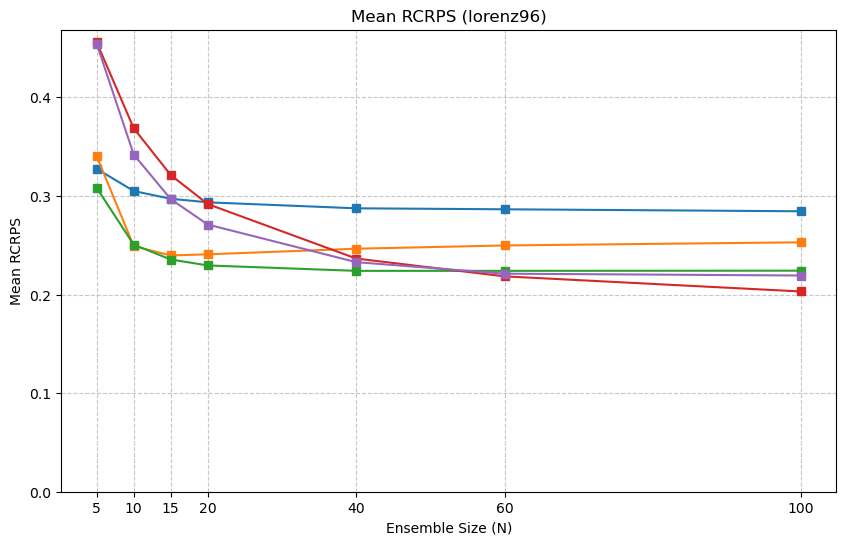

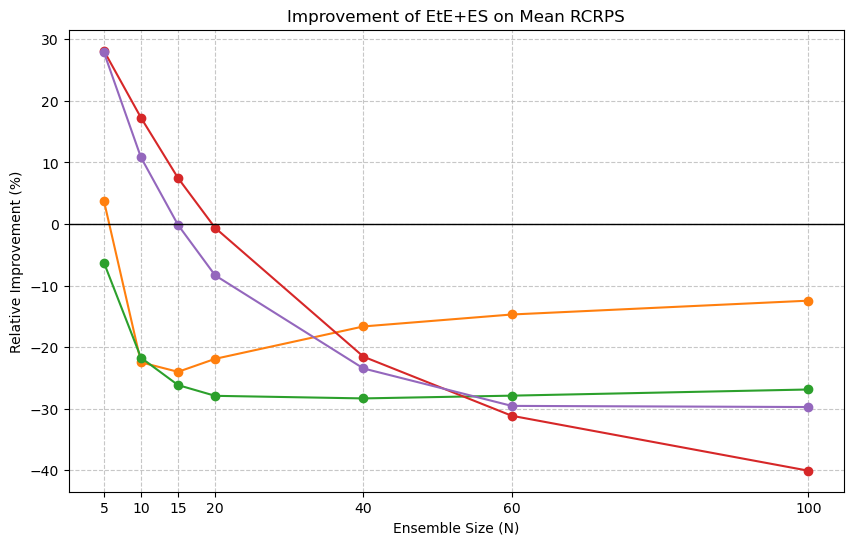

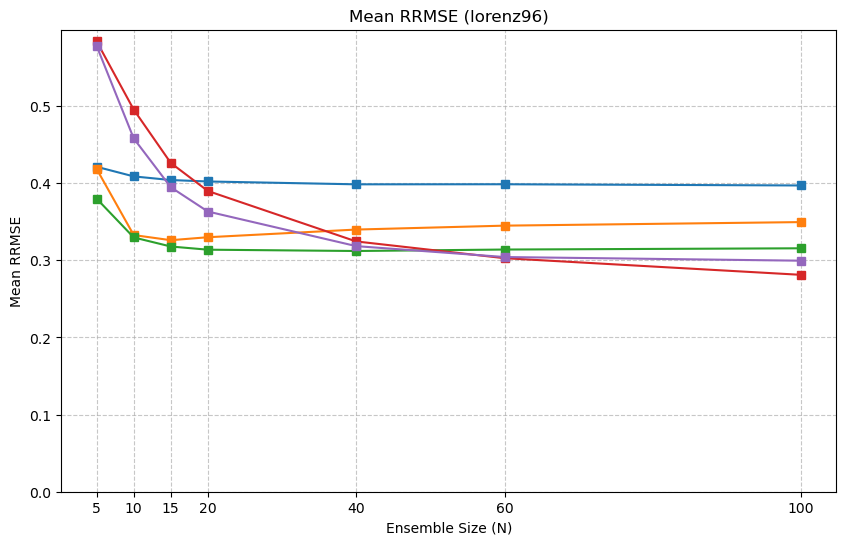

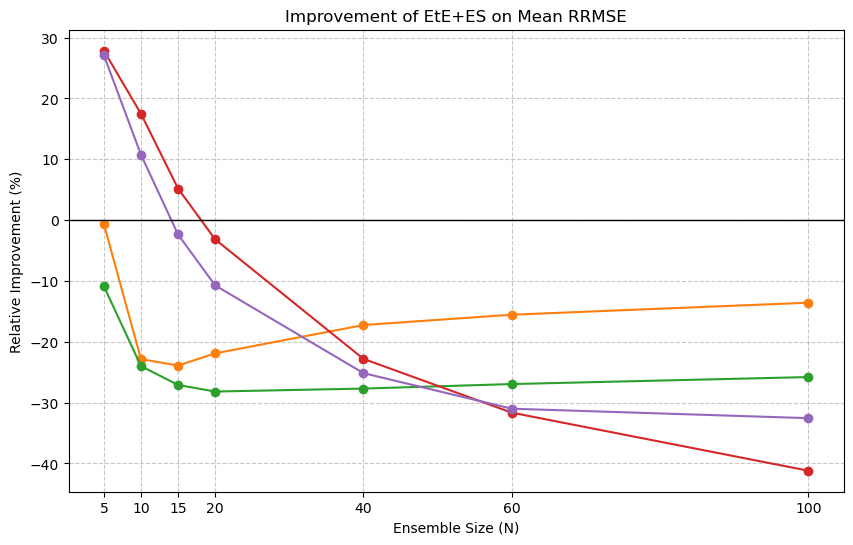

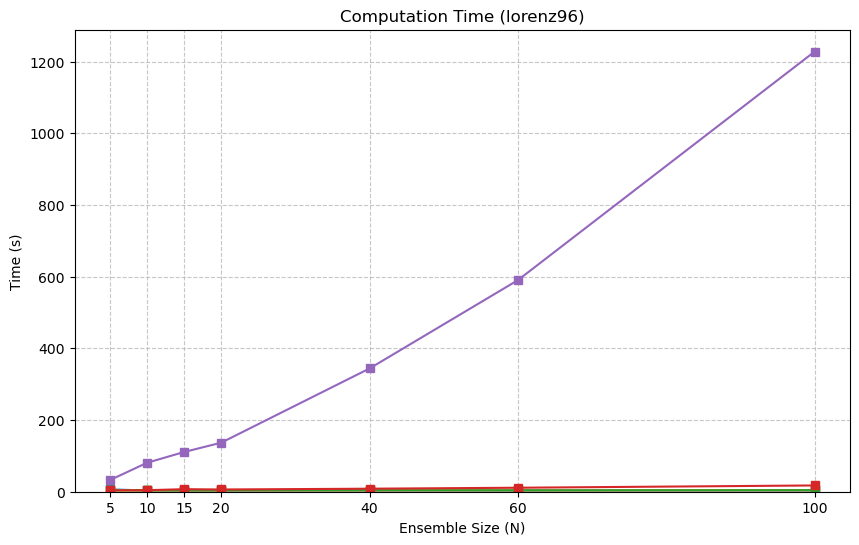

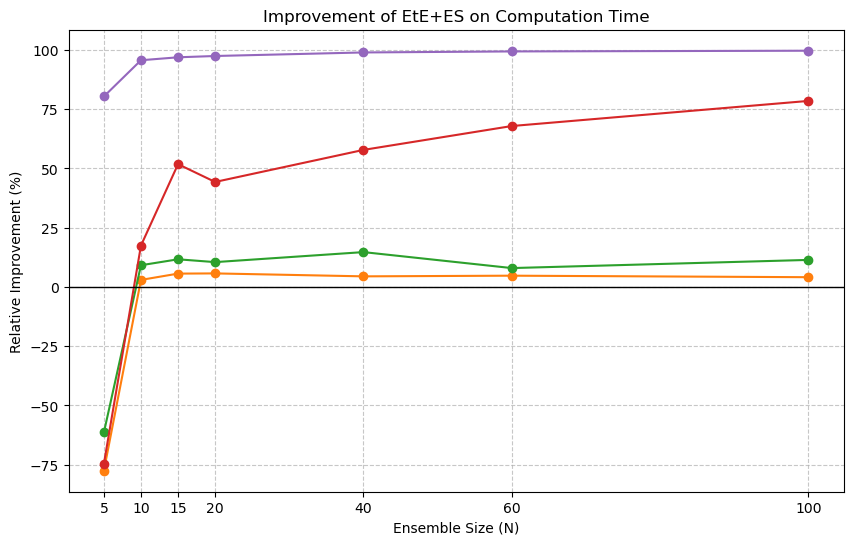

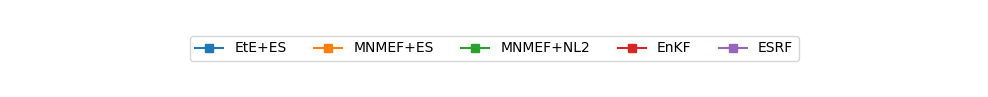

In [3]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# --- [CONFIGURATION & SETUP] ---
DATASET = "lorenz96"
SIGMA_Y = 1.0 

# Dynamic Save Path
SAVE_DIR = os.path.join("save", "figures", f"{DATASET}_sigma{SIGMA_Y}")
os.makedirs(SAVE_DIR, exist_ok=True)

ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "lorenz96_EtE_LRes/2026-01-07_16-42lorenz96_1.0_10_60_8192_es_joint_EtE-LRes",
    "lorenz96_EtE_LRes/2026-01-14_01-24lorenz96_1.0_10_60_8192_es_joint_CorrTerms",
    "lorenz96_EtE_LRes/2026-01-07_17-39lorenz96_1.0_10_60_8192_nl2_joint_CorrTerms",
    "lorenz96_benchmarks/benchmark_lorenz96_1.0_EnKF",
    "lorenz96_benchmarks/benchmark_lorenz96_1.0_LETKF",
    # "lorenz96_benchmarks/benchmark_lorenz96_1.0_iEnKS-PertObs",
]

method_names = [
    'EtE+ES', 
    'MNMEF+ES',
    'MNMEF+NL2',
    "EnKF",
    "ESRF",
    # "iEnKF-PertObs",
]

TARGET_METHOD = 'EtE+ES' 

# --- [COLOR MAPPING SETUP] ---
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
METHOD_COLORS = {name: colors[i % len(colors)] for i, name in enumerate(method_names)}

# --- [DATA LOADING] ---
results = {}

print(f"Current Working Directory: {os.getcwd()}")

for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        if not os.path.exists(data_file):
            print(f"\n[MISSING] File not found for {method_name} (N={ens_size})")
            continue

        try:
            data = torch.load(data_file, weights_only=True)
            
            # --- EXTRACT METRICS ---
            # Using .get() for safety, though keys should exist
            mean_rcrps = data["nn"].get('mean_rcrps', float('nan'))
            mean_rrmse = data["nn"].get('mean_rrmse', float('nan')) # New Metric
            t = data["time"]

            # Initialize
            results.setdefault(method_name, {})
            for key in ['mean_rcrps', 'mean_rrmse', 'time']:
                results[method_name].setdefault(key, [])

            # Append
            results[method_name]['mean_rcrps'].append(mean_rcrps)
            results[method_name]['mean_rrmse'].append(mean_rrmse)
            results[method_name]['time'].append(t)
            
        except Exception as e:
            print(f"\n[ERROR] Failed to load {filename}: {e}")
            continue

if not results:
    raise RuntimeError("No data loaded.")
else:
    print(f"\nSuccessfully loaded data for: {list(results.keys())}")

# --- [HELPER FUNCTIONS] ---
def save_figure_and_log(fig, filename):
    path_pdf = os.path.join(SAVE_DIR, f"{filename}.pdf")
    path_png = os.path.join(SAVE_DIR, f"{filename}.png")
    fig.savefig(path_pdf, bbox_inches='tight', format='pdf')
    fig.savefig(path_png, bbox_inches='tight', format='png', dpi=300)
    print(f"[Saved] {filename}")

def calculate_relative_improvement(metric_key):
    if TARGET_METHOD not in results:
        return {}
    psef_vals = np.array(results[TARGET_METHOD][metric_key])
    imp_data = {}
    for method in results.keys():
        if method == TARGET_METHOD: continue 
        bench_vals = np.array(results[method][metric_key])
        improvement = (bench_vals - psef_vals) / bench_vals * 100
        imp_data[method] = improvement
    return imp_data

def plot_metric_pair(metric_key, title_label, filename_base, ylabel=None):
    """
    Plots both the Absolute value and Relative Improvement for a given metric side-by-side in code execution
    (saves as two separate files).
    """
    if ylabel is None: ylabel = title_label

    # --- 1. ABSOLUTE PLOT ---
    fig_abs, ax_abs = plt.subplots(figsize=(10, 6))
    for key in results.keys():
        if metric_key in results[key]:
            ax_abs.plot(ensemble_sizes, results[key][metric_key], marker='s', label=key, color=METHOD_COLORS[key])
    
    ax_abs.set_title(f'{title_label} ({DATASET})')
    ax_abs.set_xlabel('Ensemble Size (N)')
    ax_abs.set_ylabel(ylabel)
    ax_abs.set_xticks(ensemble_sizes)
    ax_abs.set_ylim(bottom=0)
    ax_abs.grid(True, linestyle='--', alpha=0.7)
    save_figure_and_log(fig_abs, f"{filename_base}_absolute_sigma_{SIGMA_Y}")

    # --- 2. RELATIVE IMPROVEMENT PLOT ---
    imp_data = calculate_relative_improvement(metric_key)
    if imp_data:
        fig_rel, ax_rel = plt.subplots(figsize=(10, 6))
        for key, val in imp_data.items():
            ax_rel.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
        
        ax_rel.set_title(f'Improvement of {TARGET_METHOD} on {title_label}')
        ax_rel.set_xlabel('Ensemble Size (N)')
        ax_rel.set_ylabel('Relative Improvement (%)')
        ax_rel.set_xticks(ensemble_sizes)
        ax_rel.grid(True, linestyle='--', alpha=0.7)
        ax_rel.axhline(0, color='black', linewidth=1, linestyle='-') 
        save_figure_and_log(fig_rel, f"{filename_base}_improvement_sigma_{SIGMA_Y}")

# --- [PLOTTING EXECUTION] ---

# Group 1: Mean RCRPS
plot_metric_pair(
    metric_key='mean_rcrps', 
    title_label='Mean RCRPS', 
    filename_base='mean_rcrps'
)

# Group 2: Mean RRMSE (New)
plot_metric_pair(
    metric_key='mean_rrmse', 
    title_label='Mean RRMSE', 
    filename_base='mean_rrmse'
)

# Group 3: Computation Time
plot_metric_pair(
    metric_key='time', 
    title_label='Computation Time', 
    filename_base='time',
    ylabel='Time (s)'
)

# --- [SHARED LEGEND] ---
# Generate one legend file based on the first plot
# We create a dummy figure just to extract handles
dummy_fig, dummy_ax = plt.subplots()
for key in results.keys():
    dummy_ax.plot([], [], marker='s', label=key, color=METHOD_COLORS[key])
handles, labels = dummy_ax.get_legend_handles_labels()
plt.close(dummy_fig)

fig_leg = plt.figure(figsize=(len(labels) * 2.5, 1.0))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
ax_leg.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
save_figure_and_log(fig_leg, f"shared_legend_sigma_{SIGMA_Y}")

print("\nProcessing complete.")

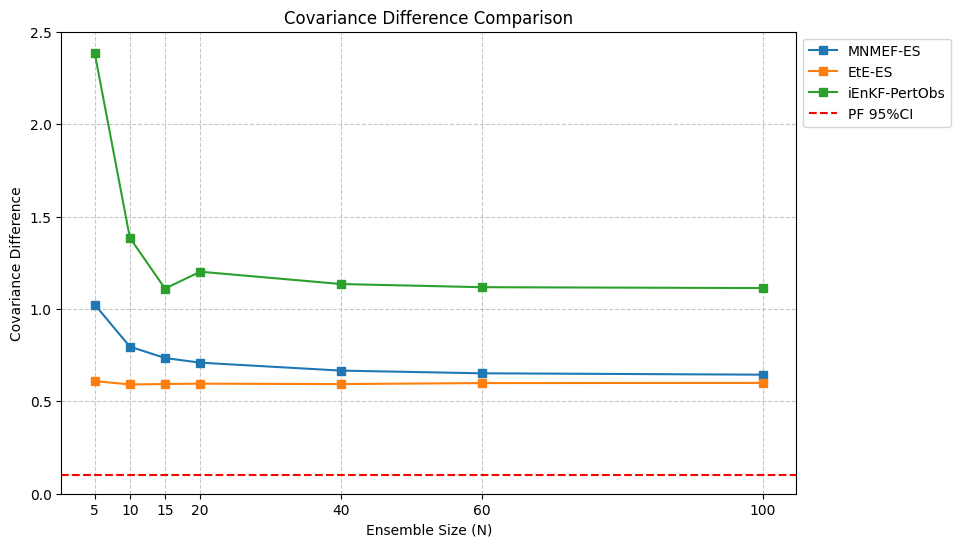

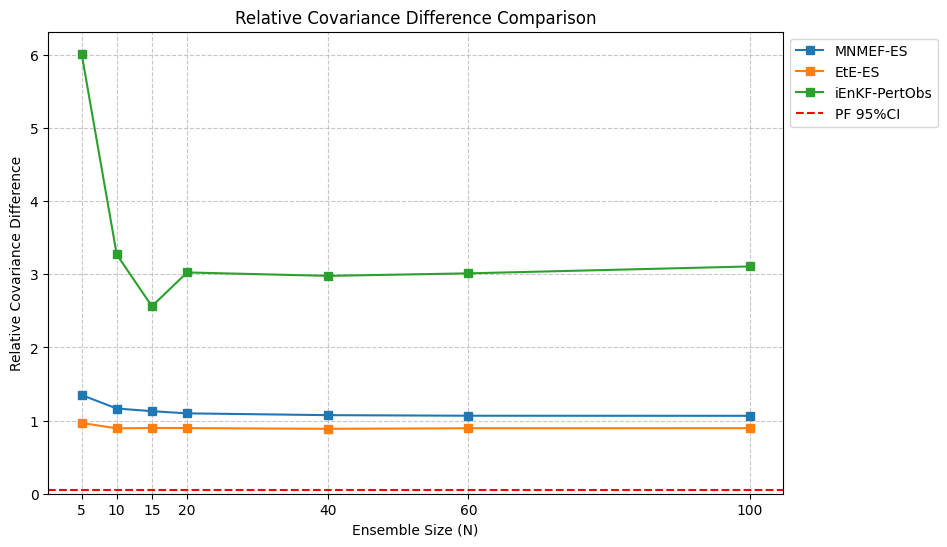

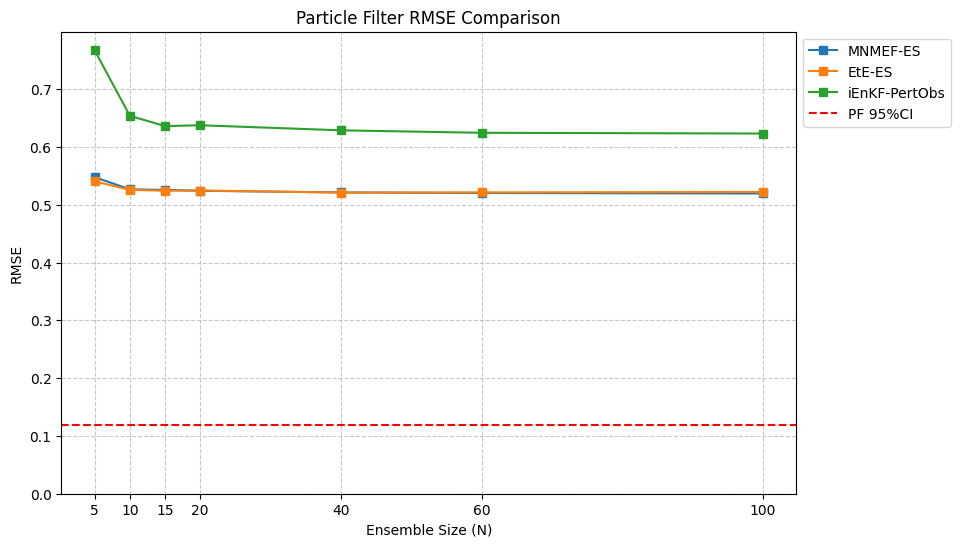

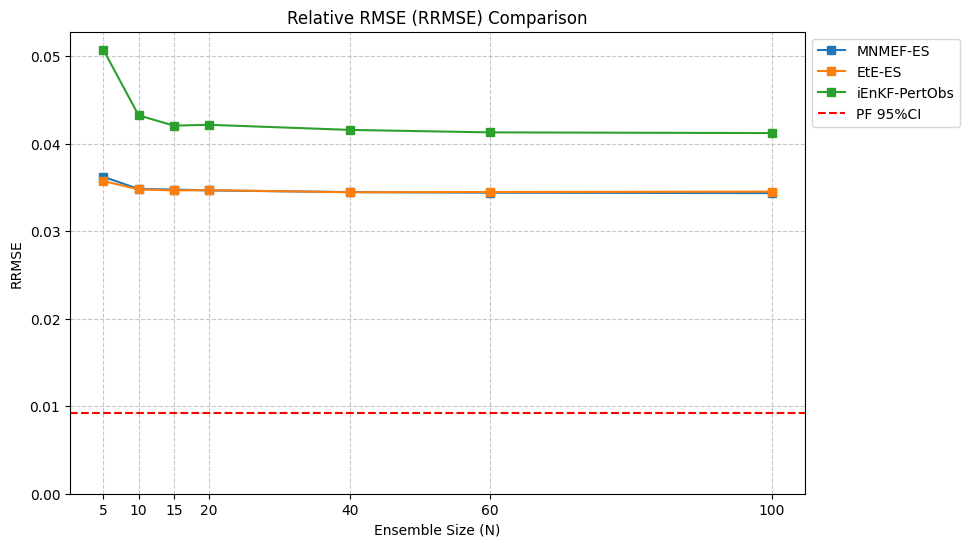

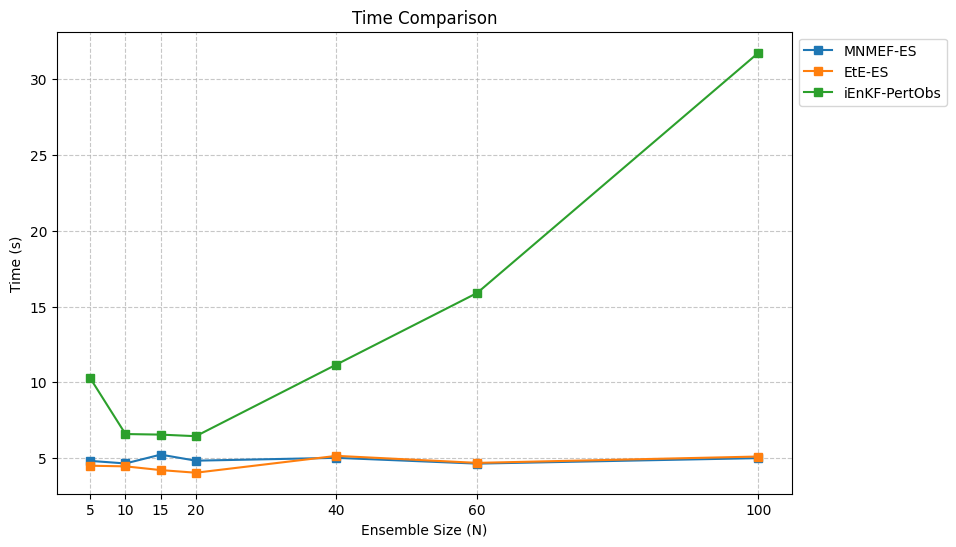

In [7]:
import os
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# --- [DATA LOADING AND PREPARATION - UNCHANGED EXCEPT NEW METRICS] ---
PF_RMSE_95CI = 0.119728
PF_Cov_Diff_95CI = 0.10073
PF_RRMSE_95CI = 0.00927624
PF_RCov_Diff_95CI = 0.0572706
ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
    "lorenz63_EtE_LRes/2025-07-09_19-08lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst",
    # "lorenz63_EtE_LRes/2025-08-08_09-55lorenz63_1.0_20_60_8192_nl2_joint_EtE-LRes_nst_tuned",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_iEnKS-PertObs",
]

method_names = [
    'MNMEF-ES',
    'EtE-ES',        # always nst
    # 'EtE-ES-FT',
    "iEnKF-PertObs",
]

results = {}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        # Load file
        data = torch.load(data_file, weights_only=True)

        # Required metrics
        cov_diff = data["nn"]['cov_diff']
        pf_rmse = data["nn"]['pf_rmse']
        t = data["time"]

        # Optional relative metrics (preferred if present)
        rrmse = data["nn"].get('pf_rrmse', float('nan'))
        rcov_diff = data["nn"].get('rcov_diff', float('nan'))

        # Initialize buckets
        results.setdefault(method_name, {})
        for key in ['cov_diff', 'pf_rmse', 'rrmse', 'rcov_diff', 'time']:
            results[method_name].setdefault(key, [])

        # Append metrics
        results[method_name]['cov_diff'].append(cov_diff)
        results[method_name]['pf_rmse'].append(pf_rmse)
        results[method_name]['rrmse'].append(rrmse)
        results[method_name]['rcov_diff'].append(rcov_diff)
        results[method_name]['time'].append(t)

# --- Figure 1: Covariance Difference ---
fig1, ax1 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key)
ax1.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax1.set_title('Covariance Difference Comparison')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig1.subplots_adjust(right=0.65)

# --- Figure 2: Relative Covariance Difference (NEW) ---
# NOTE: Per request, ax4 -> ax2
fig4, ax2 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax2.plot(ensemble_sizes, results[key]['rcov_diff'], marker='s', label=key)
ax2.axhline(y=PF_RCov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax2.set_title('Relative Covariance Difference Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('Relative Covariance Difference')
ax2.set_xticks(ensemble_sizes)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig4.subplots_adjust(right=0.65)

# --- Figure 2: Particle Filter RMSE ---
# NOTE: Per request, ax2 -> ax4
fig2, ax4 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax4.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s', label=key)
ax4.axhline(y=PF_RMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax4.set_title('Particle Filter RMSE Comparison')
ax4.set_xlabel('Ensemble Size (N)')
ax4.set_ylabel('RMSE')
ax4.set_xticks(ensemble_sizes)
ax4.set_ylim(bottom=0)
ax4.grid(True, linestyle='--', alpha=0.7)
ax4.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig2.subplots_adjust(right=0.65)

# --- Figure 3: Relative RMSE (NEW) ---
fig3, ax3 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax3.plot(ensemble_sizes, results[key]['rrmse'], marker='s', label=key)
ax3.axhline(y=PF_RRMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax3.set_title('Relative RMSE (RRMSE) Comparison')
ax3.set_xlabel('Ensemble Size (N)')
ax3.set_ylabel('RRMSE')
ax3.set_xticks(ensemble_sizes)
ax3.set_ylim(bottom=0)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig3.subplots_adjust(right=0.65)

# --- Figure 5: Time ---
fig5, ax5 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax5.plot(ensemble_sizes, results[key]['time'], marker='s', label=key)
ax5.set_title('Time Comparison')
ax5.set_xlabel('Ensemble Size (N)')
ax5.set_ylabel('Time (s)')
ax5.set_xticks(ensemble_sizes)
ax5.grid(True, linestyle='--', alpha=0.7)
ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig5.subplots_adjust(right=0.65)

# Show all plots
plt.show()
